
# 00 — การเตรียมชุดข้อมูล SRTM DEM จาก Zenodo สำหรับการวิเคราะห์ Radar–Terrain Beam Blockage

**Google Colab teaching notebook | Geography · Geoinformatics · Environmental Science · Radar Meteorology**

Notebook นี้เป็นจุดเริ่มต้นของชุดแบบเรียน **Weather Radar–Terrain–GIS Analysis**  
มีวัตถุประสงค์เพื่อเตรียมข้อมูลภูมิประเทศให้มีโครงสร้างที่ถูกต้อง ตรวจสอบย้อนกลับได้ และพร้อมใช้ใน Notebook ถัดไป

> **หลักสำคัญ:** Notebook นี้ยัง **ไม่ทำ mosaic, reprojection หรือ resampling**  
> หน้าที่หลักคือ **ดาวน์โหลด → ตรวจสอบ → แตกไฟล์ → ตรวจ inventory → ตรวจ metadata → สร้าง quick-look QC**

---

## ชุดข้อมูลที่ใช้

**Zenodo DOI:** `10.5281/zenodo.22687421`  
**Record ID:** `22687421`  
**Target archive:** `dem_beamblockage_teaching.zip`

[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.22687421.svg)](https://doi.org/10.5281/zenodo.22687421)

ข้อมูลภูมิประเทศมีพื้นฐานจาก **Shuttle Radar Topography Mission (SRTM)** ซึ่งเป็นภารกิจเรดาร์อินเตอร์เฟอโรเมตรีจากอวกาศสำหรับสร้างข้อมูลระดับความสูงของพื้นผิวโลก

สำหรับ SRTM global product ที่ความละเอียดประมาณ 90 m:

- Horizontal datum: **WGS 84**
- Vertical datum: **EGM96**
- Vertical unit: **metres**
- Nominal spatial resolution: **3 arc-seconds (~90 m)**

Notebook ถัดไปจะนำ DEM เหล่านี้ไปสร้าง analysis grid สำหรับงาน weather-radar beam blockage



## 1. เป้าหมายการเรียนรู้ (Learning Outcomes)

เมื่อจบ Notebook นี้ นิสิตควรสามารถ:

1. อธิบายความแตกต่างระหว่าง **GitHub, Zenodo, Google Colab และ Google Drive** ใน workflow งานวิจัยที่ reproducible ได้
2. ใช้ **DOI/Zenodo record** เพื่อระบุแหล่งข้อมูลต้นฉบับอย่างเป็นระบบ
3. ดาวน์โหลดไฟล์ขนาดใหญ่จาก Zenodo ไปยัง Google Drive โดยไม่ต้องเก็บ DEM ไว้ใน GitHub
4. ตรวจสอบ **file size และ checksum** เพื่อประเมินความสมบูรณ์ของไฟล์
5. ตรวจสอบโครงสร้างข้อมูล `.tif`, `.tfw`, `.hdr`
6. อ่าน spatial metadata เบื้องต้นของ GeoTIFF เช่น CRS, pixel size, bounds และ NoData
7. สร้าง metadata inventory ที่นำไปใช้ต่อในงาน GIS และ radar analysis ได้

---

### แนวคิดของ Data Architecture

```text
GitHub
  │
  │  Notebook / code / README
  ▼
Google Colab
  │
  ├──────── ดาวน์โหลดข้อมูล ────────► Zenodo
  │                                  DOI / version / checksum
  ▼
Google Drive
  │
  ├── 00_raw_data/
  ├── 01_processed_data/
  ├── 02_metadata/
  ├── 03_results/
  ├── 04_figures/
  └── 05_tables/
```

แนวคิดนี้ช่วยแยก **code** ออกจาก **large research data** และทำให้ผู้เรียนหรือผู้วิจัยคนอื่นสามารถทำซ้ำ workflow เดียวกันได้



## 2. หลักการเบื้องต้น: DEM และ SRTM

Digital Elevation Model (DEM) สามารถมองเป็นฟังก์ชันเชิงพื้นที่

\[
z = f(x,y)
\]

โดยที่

- \(x,y\) คือพิกัดเชิงพื้นที่
- \(z\) คือค่าระดับความสูงของภูมิประเทศ

ในการวิเคราะห์ radar beam blockage เราจะต้องเปรียบเทียบ **ระดับความสูงของลำบีมเรดาร์** กับ **ระดับภูมิประเทศ** ดังนั้น datum และหน่วยของ DEM จึงมีความสำคัญโดยตรง

ใน workflow นี้ DEM ต้นฉบับยังคงอยู่ใน geographic coordinate system ก่อน  
จากนั้น Notebook 01 จะพาไปสู่

\[
\text{SRTM geographic grid}
\rightarrow
\text{projected metric grid}
\rightarrow
\text{1-km analysis DEM}
\]

เพื่อให้การวิเคราะห์ระยะทางและ radar geometry อยู่ในหน่วยเมตรอย่างสอดคล้องกัน



## 3. มาตรฐานการสร้างภาพของชุดแบบเรียน

ชุด Notebook นี้จะใช้ visual convention เดียวกันตลอดทั้งหลักสูตร

- **DEM / Terrain:** `terrain`
- **PBB / CBB:** `PuRd`
- **PBB/CBB range:** 0–1

เหตุผลคือให้ figure ในทุกบทมีความสม่ำเสมอ และสามารถนำไปปรับใช้ในรายงานวิจัยหรือ manuscript ได้ง่าย


In [1]:

# ============================================================
# STEP 1 — Install only packages that may be missing in Colab
# ============================================================
# ไม่ใช้ -U / --upgrade เพื่อหลีกเลี่ยงการเปลี่ยน package หลักของ Colab
# โดยไม่จำเป็น

import sys
import subprocess
import importlib.util

required_packages = {
    "rasterio": "rasterio",
    "tqdm": "tqdm",
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", package_name
        ])

print("✓ Package check complete")


✓ Package check complete


In [2]:

# ============================================================
# STEP 2 — Imports and software environment
# ============================================================

from pathlib import Path
import os
import sys
import json
import hashlib
import zipfile
import shutil
import platform
import re

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling
from tqdm.auto import tqdm

print("Software environment")
print("--------------------")
print("Python      :", platform.python_version())
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Matplotlib  :", plt.matplotlib.__version__)
print("Rasterio    :", rasterio.__version__)
print("Requests    :", requests.__version__)


Software environment
--------------------
Python      : 3.13.15
NumPy       : 2.1.3
Pandas      : 2.2.3
Matplotlib  : 3.10.0
Rasterio    : 1.5.1
Requests    : 2.32.4


In [3]:

# ============================================================
# STEP 3 — Course-wide visualization convention
# ============================================================

DEM_CMAP = "terrain"

BLOCKAGE_CMAP = "PuRd"
BLOCKAGE_VMIN = 0.0
BLOCKAGE_VMAX = 1.0

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

print("DEM colormap       :", DEM_CMAP)
print("Beam-blockage cmap :", BLOCKAGE_CMAP)
print("Beam-blockage range:", (BLOCKAGE_VMIN, BLOCKAGE_VMAX))


DEM colormap       : terrain
Beam-blockage cmap : PuRd
Beam-blockage range: (0.0, 1.0)



## 4. เชื่อมต่อ Google Drive

Google Drive จะใช้เป็น **working storage** ของนิสิต

ข้อมูล DEM จะดาวน์โหลดเพียงครั้งแรกจาก Zenodo แล้วเก็บไว้ใน Drive  
Notebook ถัดไปจึงสามารถอ่านข้อมูลจาก path เดิมได้โดยไม่ต้องดาวน์โหลดซ้ำ


In [4]:

# ============================================================
# STEP 4 — Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive



## 5. กำหนดโครงสร้างโครงการ

เพื่อให้ Notebook ของทุกคนใช้ path เดียวกัน เราจะสร้างโครงสร้างมาตรฐานดังนี้

```text
Teaching_Radar_Terrain_BeamBlockage/
│
├── 00_raw_data/
│   ├── download/
│   └── srtm90/
│
├── 01_processed_data/
│   └── dem/
│
├── 02_metadata/
├── 03_results/
├── 04_figures/
└── 05_tables/
```

**Raw data จะไม่ถูกแก้ไขโดยตรง**  
ผลิตภัณฑ์ที่ผ่าน processing แล้วต้องบันทึกใน `01_processed_data/`


In [5]:

# ============================================================
# STEP 5 — Project configuration
# ============================================================

COURSE_ROOT = Path(
    "/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage"
)

RAW_DIR = COURSE_ROOT / "00_raw_data"
DOWNLOAD_DIR = RAW_DIR / "download"
SRTM_DIR = RAW_DIR / "srtm90"

PROCESSED_DEM_DIR = COURSE_ROOT / "01_processed_data" / "dem"
METADATA_DIR = COURSE_ROOT / "02_metadata"
RESULTS_DIR = COURSE_ROOT / "03_results"
FIGURES_DIR = COURSE_ROOT / "04_figures"
TABLES_DIR = COURSE_ROOT / "05_tables"

for folder in [
    DOWNLOAD_DIR,
    SRTM_DIR,
    PROCESSED_DEM_DIR,
    METADATA_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

ZENODO_RECORD_ID = "22687421"
ZENODO_DOI = "10.5281/zenodo.22687421"
TARGET_ARCHIVE = "dem_beamblockage_teaching.zip"

EXPECTED_TILE_STEMS = [
    "srtm_56_08",
    "srtm_56_09",
    "srtm_56_10",
    "srtm_57_08",
    "srtm_57_09",
    "srtm_57_10",
]

EXPECTED_EXTENSIONS = [".tif", ".tfw", ".hdr"]

print("Project root :", COURSE_ROOT)
print("Raw SRTM dir :", SRTM_DIR)
print("Zenodo DOI   :", ZENODO_DOI)
print("Record ID    :", ZENODO_RECORD_ID)


Project root : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage
Raw SRTM dir : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/00_raw_data/srtm90
Zenodo DOI   : 10.5281/zenodo.22687421
Record ID    : 22687421



## 6. อ่าน metadata ของ Zenodo record

แทนที่จะ hard-code direct-download URL เราจะใช้ Zenodo API เพื่ออ่าน:

- ชื่อ record
- DOI
- filename
- file size
- checksum
- download link

นี่เป็นแนวทางที่เหมาะกับ **reproducible research** มากกว่า เพราะ Notebook สามารถตรวจสอบ record ก่อนดาวน์โหลดได้


In [6]:

# ============================================================
# STEP 6 — Query Zenodo record metadata
# ============================================================

ZENODO_API_URL = f"https://zenodo.org/api/records/{ZENODO_RECORD_ID}"

response = requests.get(ZENODO_API_URL, timeout=60)
response.raise_for_status()
record = response.json()

record_title = record.get("metadata", {}).get("title", "N/A")
record_doi = record.get("doi", record.get("metadata", {}).get("doi", "N/A"))
record_version = record.get("metadata", {}).get("version", "N/A")

files = record.get("files", [])

print("=" * 72)
print("ZENODO DATASET")
print("=" * 72)
print("Title      :", record_title)
print("DOI        :", record_doi)
print("Version    :", record_version)
print("Record ID  :", ZENODO_RECORD_ID)
print("No. files  :", len(files))
print("=" * 72)

if str(record_doi).strip() not in {ZENODO_DOI, "N/A"}:
    print(
        "⚠ DOI returned by the API differs from the DOI configured "
        "in this notebook. Check the Zenodo record before proceeding."
    )


ZENODO DATASET
Title      : SRTM 90 m DEM for Northern Thailand: A Teaching and Research Dataset for Weather Radar Beam-Blockage Analysis
DOI        : 10.5281/zenodo.22687421
Version    : N/A
Record ID  : 22687421
No. files  : 1


In [7]:

# ============================================================
# STEP 7 — Inspect files in the Zenodo record
# ============================================================

file_rows = []

for f in files:
    links = f.get("links", {})
    file_rows.append({
        "filename": f.get("key", f.get("filename", "")),
        "size_bytes": f.get("size", np.nan),
        "size_MB": (
            f.get("size", np.nan) / 1024**2
            if isinstance(f.get("size"), (int, float))
            else np.nan
        ),
        "checksum": f.get("checksum", ""),
        "download_url": (
            links.get("content")
            or links.get("self")
            or links.get("download")
            or ""
        ),
    })

zenodo_files = pd.DataFrame(file_rows)

if zenodo_files.empty:
    raise RuntimeError("No files were returned by the Zenodo record.")

display(
    zenodo_files[
        ["filename", "size_MB", "checksum"]
    ].style.format({"size_MB": "{:.2f}"})
)

matches = zenodo_files[
    zenodo_files["filename"] == TARGET_ARCHIVE
].copy()

if len(matches) != 1:
    raise RuntimeError(
        f"Expected exactly one file named {TARGET_ARCHIVE!r}, "
        f"but found {len(matches)}."
    )

target = matches.iloc[0]

print("\nTarget archive")
print("--------------")
print("Filename :", target["filename"])
print("Size     :", f'{target["size_MB"]:.2f} MB')
print("Checksum :", target["checksum"])


,filename,size_MB,checksum
0,dem_beamblockage_teaching.zip,197.57,md5:c2e4efa127d69694853b9ad0f0e1c972



Target archive
--------------
Filename : dem_beamblockage_teaching.zip
Size     : 197.57 MB
Checksum : md5:c2e4efa127d69694853b9ad0f0e1c972



## 7. ดาวน์โหลดไฟล์ DEM

โค้ดต่อไปนี้ใช้ **streaming download** จึงไม่ต้องโหลดไฟล์ทั้งหมดเข้าสู่ RAM

หากไฟล์มีอยู่แล้วและมีขนาดตรงกับ Zenodo Notebook จะไม่ดาวน์โหลดซ้ำ  
เหมาะสำหรับการใช้งานในชั้นเรียนที่นักศึกษาอาจเปิด Notebook หลายครั้ง


In [8]:

# ============================================================
# STEP 8 — Download the archive to Google Drive
# ============================================================

archive_path = DOWNLOAD_DIR / TARGET_ARCHIVE
expected_size = int(target["size_bytes"])
download_url = target["download_url"]

if not download_url:
    raise RuntimeError("Zenodo API did not return a usable download URL.")

need_download = True

if archive_path.exists():
    local_size = archive_path.stat().st_size

    if local_size == expected_size:
        print("✓ Archive already exists with the expected file size.")
        print("  Skipping download:", archive_path)
        need_download = False
    else:
        print("⚠ Existing archive has a different file size.")
        print("  Local   :", f"{local_size / 1024**2:.2f} MB")
        print("  Zenodo  :", f"{expected_size / 1024**2:.2f} MB")
        print("  The file will be downloaded again.")

if need_download:
    temporary_path = archive_path.with_suffix(
        archive_path.suffix + ".part"
    )

    with requests.get(
        download_url,
        stream=True,
        timeout=(30, 300)
    ) as r:
        r.raise_for_status()

        total = int(r.headers.get("content-length", expected_size or 0))

        with open(temporary_path, "wb") as f, tqdm(
            total=total,
            unit="B",
            unit_scale=True,
            unit_divisor=1024,
            desc="Downloading SRTM DEM"
        ) as progress:

            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    progress.update(len(chunk))

    temporary_path.replace(archive_path)

    print("\n✓ Download complete")
    print("  Saved:", archive_path)
    print("  Size :", f"{archive_path.stat().st_size / 1024**2:.2f} MB")



✓ Download complete
  Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/00_raw_data/download/dem_beamblockage_teaching.zip
  Size : 197.57 MB



## 8. ตรวจ checksum

Checksum คือ digital fingerprint ของไฟล์

ถ้า checksum ของไฟล์ที่ดาวน์โหลดตรงกับค่าที่ Zenodo ระบุ  
เรามีหลักฐานว่าไฟล์ไม่ได้เสียหายหรือเปลี่ยนแปลงระหว่างการดาวน์โหลด

Zenodo มักรายงาน checksum ในรูป เช่น

```text
md5:xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
```


In [9]:

# ============================================================
# STEP 9 — Verify checksum
# ============================================================

def calculate_checksum(path, algorithm="md5", chunk_size=1024 * 1024):
    h = hashlib.new(algorithm)

    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)

    return h.hexdigest()


checksum_text = str(target["checksum"]).strip()

if ":" in checksum_text:
    checksum_algorithm, expected_hash = checksum_text.split(":", 1)
else:
    checksum_algorithm, expected_hash = "md5", checksum_text

checksum_algorithm = checksum_algorithm.lower().strip()
expected_hash = expected_hash.lower().strip()

print("Checksum algorithm :", checksum_algorithm)
print("Expected checksum  :", expected_hash)
print("Calculating checksum...")

local_hash = calculate_checksum(
    archive_path,
    algorithm=checksum_algorithm
)

print("Local checksum     :", local_hash)

if expected_hash and local_hash == expected_hash:
    print("\n✓ CHECKSUM PASSED — downloaded archive matches Zenodo.")
elif not expected_hash:
    print("\n⚠ Zenodo did not provide a checksum value.")
else:
    raise RuntimeError(
        "CHECKSUM FAILED. Delete the archive and download it again."
    )


Checksum algorithm : md5
Expected checksum  : c2e4efa127d69694853b9ad0f0e1c972
Calculating checksum...
Local checksum     : c2e4efa127d69694853b9ad0f0e1c972

✓ CHECKSUM PASSED — downloaded archive matches Zenodo.



## 9. ตรวจ ZIP และแตกข้อมูล

ก่อน extract จะใช้ `ZipFile.testzip()` ตรวจสอบโครงสร้างภายใน archive

หลังจากนั้นจะ extract ไปยัง

```text
00_raw_data/srtm90/
```

โดย raw data ชุดนี้ควรถูกเก็บไว้โดยไม่แก้ไข เพื่อให้ Notebook ถัดไปสามารถย้อนกลับมายัง source data เดิมได้


In [10]:

# ============================================================
# STEP 10 — Test and extract ZIP archive
# ============================================================

with zipfile.ZipFile(archive_path, "r") as z:
    bad_file = z.testzip()

    if bad_file is not None:
        raise RuntimeError(
            f"ZIP integrity test failed at: {bad_file}"
        )

    members = [
        name for name in z.namelist()
        if not name.endswith("/")
    ]

print("✓ ZIP integrity test passed")
print("Files inside archive:", len(members))

# Determine whether expected source files are already present.
expected_paths = [
    SRTM_DIR / f"{stem}{ext}"
    for stem in EXPECTED_TILE_STEMS
    for ext in EXPECTED_EXTENSIONS
]

all_expected_present = all(p.exists() for p in expected_paths)

if all_expected_present:
    print("✓ Expected SRTM source files are already extracted.")
    print("  Extraction skipped.")
else:
    print("Extracting archive...")

    with zipfile.ZipFile(archive_path, "r") as z:
        for member in tqdm(z.infolist(), desc="Extracting"):
            if member.is_dir():
                continue

            # Flatten the archive to the standard teaching folder.
            target_name = Path(member.filename).name

            if not target_name:
                continue

            destination = SRTM_DIR / target_name

            with z.open(member) as src, open(destination, "wb") as dst:
                shutil.copyfileobj(src, dst)

    print("✓ Extraction complete")
    print("  Folder:", SRTM_DIR)


✓ ZIP integrity test passed
Files inside archive: 18
Extracting archive...


Extracting:   0%|          | 0/18 [00:00<?, ?it/s]

✓ Extraction complete
  Folder: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/00_raw_data/srtm90



## 10. ตรวจ Data Inventory

สำหรับชุดแบบเรียนนี้คาดหวัง 6 SRTM tiles

\[
6\ \text{tiles}
\times
3\ \text{files per tile}
=
18\ \text{files}
\]

แต่ละ tile ต้องมี

- `.tif` — raster elevation data
- `.tfw` — world file / georeferencing support
- `.hdr` — header / ancillary metadata

หากมีไฟล์ขาด จะหยุด workflow ก่อนทำ DEM preprocessing


In [11]:

# ============================================================
# STEP 11 — Validate expected file inventory
# ============================================================

inventory_rows = []

for stem in EXPECTED_TILE_STEMS:
    row = {"tile": stem}

    for ext in EXPECTED_EXTENSIONS:
        path = SRTM_DIR / f"{stem}{ext}"
        row[ext] = path.exists()

    inventory_rows.append(row)

inventory = pd.DataFrame(inventory_rows)

display(inventory)

n_tif = len(list(SRTM_DIR.glob("srtm_*.tif")))
n_tfw = len(list(SRTM_DIR.glob("srtm_*.tfw")))
n_hdr = len(list(SRTM_DIR.glob("srtm_*.hdr")))

print("Inventory summary")
print("-----------------")
print(f"GeoTIFF (.tif): {n_tif}")
print(f"TFW     (.tfw): {n_tfw}")
print(f"HDR     (.hdr): {n_hdr}")

missing = []

for stem in EXPECTED_TILE_STEMS:
    for ext in EXPECTED_EXTENSIONS:
        p = SRTM_DIR / f"{stem}{ext}"
        if not p.exists():
            missing.append(p.name)

if missing:
    print("\nMissing files:")
    for name in missing:
        print("  ✗", name)

    raise FileNotFoundError(
        "The SRTM teaching dataset is incomplete."
    )
else:
    print("\n✓ All expected SRTM files are available.")


,tile,.tif,.tfw,.hdr
0,srtm_56_08,True,True,True
1,srtm_56_09,True,True,True
2,srtm_56_10,True,True,True
3,srtm_57_08,True,True,True
4,srtm_57_09,True,True,True
5,srtm_57_10,True,True,True


Inventory summary
-----------------
GeoTIFF (.tif): 6
TFW     (.tfw): 6
HDR     (.hdr): 6

✓ All expected SRTM files are available.



## 11. ตรวจ spatial metadata ของ GeoTIFF

ขั้นตอนนี้ยังไม่เปลี่ยน DEM

เราจะอ่านเพียง metadata เพื่อดูว่าแต่ละ tile มี:

- raster dimensions
- CRS
- pixel size
- spatial bounds
- NoData
- elevation range แบบ sampled quick check

รายละเอียดเรื่อง **TFW, affine transform, pixel centre และ pixel corner** จะสอนอย่างเป็นระบบใน Notebook 01


In [12]:

# ============================================================
# STEP 12 — Read source GeoTIFF metadata
# ============================================================

def sampled_elevation_stats(ds, sample_size=500):
    """Read a low-resolution sample for quick QC without loading full raster."""

    out_h = min(sample_size, ds.height)
    out_w = min(sample_size, ds.width)

    arr = ds.read(
        1,
        out_shape=(out_h, out_w),
        masked=True,
        resampling=Resampling.nearest,
    )

    if arr.count() == 0:
        return np.nan, np.nan, np.nan

    return (
        float(arr.min()),
        float(arr.max()),
        float(arr.mean()),
    )


meta_rows = []

for tif_path in sorted(SRTM_DIR.glob("srtm_*.tif")):
    with rasterio.open(tif_path) as ds:
        zmin, zmax, zmean = sampled_elevation_stats(ds)

        meta_rows.append({
            "tile": tif_path.stem,
            "width": ds.width,
            "height": ds.height,
            "crs": str(ds.crs),
            "pixel_x": ds.res[0],
            "pixel_y": ds.res[1],
            "left": ds.bounds.left,
            "bottom": ds.bounds.bottom,
            "right": ds.bounds.right,
            "top": ds.bounds.top,
            "nodata": ds.nodata,
            "sample_min_m": zmin,
            "sample_max_m": zmax,
            "sample_mean_m": zmean,
            "file_size_MB": tif_path.stat().st_size / 1024**2,
        })

tile_metadata = pd.DataFrame(meta_rows)

display(
    tile_metadata.style.format({
        "pixel_x": "{:.8f}",
        "pixel_y": "{:.8f}",
        "left": "{:.5f}",
        "bottom": "{:.5f}",
        "right": "{:.5f}",
        "top": "{:.5f}",
        "sample_min_m": "{:.1f}",
        "sample_max_m": "{:.1f}",
        "sample_mean_m": "{:.1f}",
        "file_size_MB": "{:.2f}",
    })
)

metadata_csv = METADATA_DIR / "00_srtm_source_tile_inventory.csv"
tile_metadata.to_csv(metadata_csv, index=False)

print("\n✓ Metadata saved:")
print(metadata_csv)


,tile,width,height,crs,pixel_x,pixel_y,left,bottom,right,top,nodata,sample_min_m,sample_max_m,sample_mean_m,file_size_MB
0,srtm_56_08,6001,6001,EPSG:4326,0.00083333,0.00083333,94.99958,19.99958,100.00042,25.00042,-32768.000000,31.0,3404.0,832.1,68.78
1,srtm_56_09,6001,6001,EPSG:4326,0.00083333,0.00083333,94.99958,14.99958,100.00042,20.00042,-32768.000000,-5.0,2524.0,383.0,68.78
2,srtm_56_10,6001,6001,EPSG:4326,0.00083333,0.00083333,94.99958,9.99958,100.00042,15.00042,-32768.000000,-28.0,1870.0,232.2,68.78
3,srtm_57_08,6001,6001,EPSG:4326,0.00083333,0.00083333,99.99958,19.99958,105.00042,25.00042,-32768.000000,24.0,3274.0,1203.5,68.78
4,srtm_57_09,6001,6001,EPSG:4326,0.00083333,0.00083333,99.99958,14.99958,105.00042,20.00042,-32768.000000,6.0,2641.0,406.9,68.78
5,srtm_57_10,6001,6001,EPSG:4326,0.00083333,0.00083333,99.99958,9.99958,105.00042,15.00042,-32768.000000,-18.0,1697.0,131.9,68.78



✓ Metadata saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/00_srtm_source_tile_inventory.csv



## 12. Figure 1 — Source-tile coverage

Figure นี้ใช้สำหรับ **spatial QC** เท่านั้น

เราต้องการตรวจว่า tiles วางต่อเนื่องกันในพื้นที่ที่คาดไว้หรือไม่  
ยังไม่ใช่ final DEM mosaic และยังไม่มีการ resampling

การตรวจ spatial coverage ก่อน preprocessing ช่วยลดความเสี่ยงจาก:

- tile ขาด
- tile ผิดพื้นที่
- georeferencing ผิด
- filename ถูกแต่ spatial extent ไม่ถูกต้อง


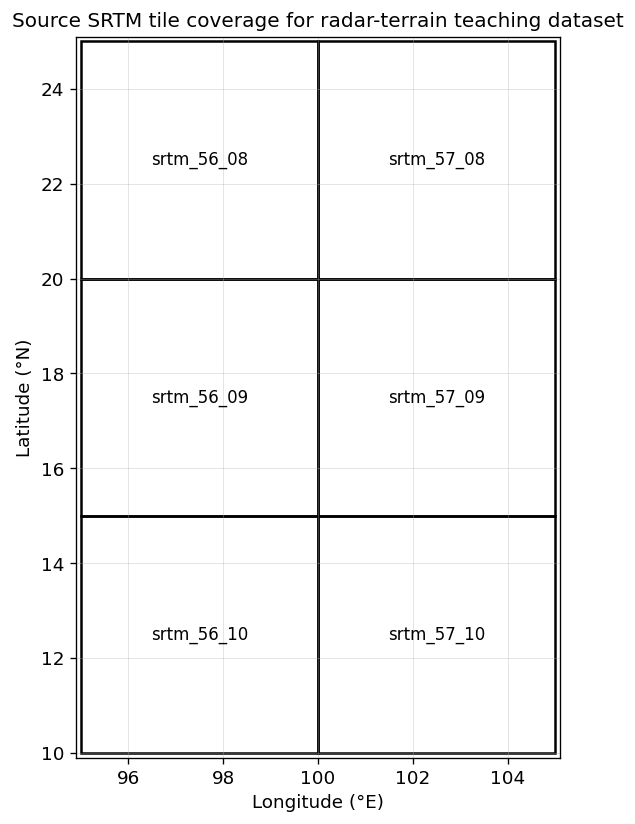

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig00_01_SRTM_Source_Tile_Coverage.png


In [13]:

# ============================================================
# STEP 13 — Plot source-tile coverage
# ============================================================

from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8.0, 7.0))

for _, row in tile_metadata.iterrows():
    width = row["right"] - row["left"]
    height = row["top"] - row["bottom"]

    rect = Rectangle(
        (row["left"], row["bottom"]),
        width,
        height,
        fill=False,
        linewidth=1.5,
    )

    ax.add_patch(rect)

    ax.text(
        row["left"] + width / 2,
        row["bottom"] + height / 2,
        row["tile"],
        ha="center",
        va="center",
        fontsize=10,
    )

ax.set_xlim(
    tile_metadata["left"].min() - 0.1,
    tile_metadata["right"].max() + 0.1,
)
ax.set_ylim(
    tile_metadata["bottom"].min() - 0.1,
    tile_metadata["top"].max() + 0.1,
)

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Source SRTM tile coverage for radar-terrain teaching dataset")
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.set_aspect("equal", adjustable="box")

fig.tight_layout()

coverage_png = FIGURES_DIR / "Fig00_01_SRTM_Source_Tile_Coverage.png"
fig.savefig(
    coverage_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:", coverage_png)



## 13. Figure 2 — DEM quick-look

ภาพนี้อ่าน DEM เพียง **ตัวอย่างแบบลดขนาด** เพื่อ QC เท่านั้น  
ยังไม่ใช่ DEM ที่จะใช้คำนวณ beam blockage

ตามมาตรฐานของชุดแบบเรียน DEM ทุกภาพใช้

```python
cmap="terrain"
```

และใช้หน่วยระดับความสูงเป็น **metres**


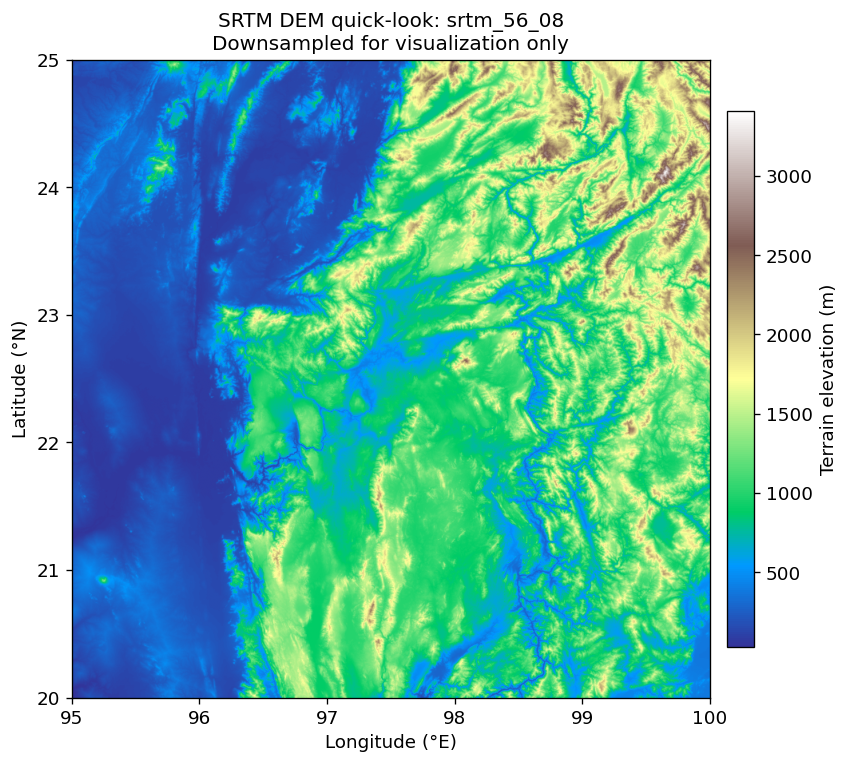

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig00_02_srtm_56_08_DEM_Quicklook.png


In [14]:

# ============================================================
# STEP 14 — Quick-look of one source DEM tile
# ============================================================

quicklook_path = sorted(SRTM_DIR.glob("srtm_*.tif"))[0]

with rasterio.open(quicklook_path) as ds:
    quicklook = ds.read(
        1,
        out_shape=(
            min(800, ds.height),
            min(800, ds.width),
        ),
        masked=True,
        resampling=Resampling.average,
    )

    extent = [
        ds.bounds.left,
        ds.bounds.right,
        ds.bounds.bottom,
        ds.bounds.top,
    ]

fig, ax = plt.subplots(figsize=(8.0, 6.5))

im = ax.imshow(
    quicklook,
    cmap=DEM_CMAP,
    extent=extent,
    origin="upper",
)

cbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.84,
    pad=0.02,
)

cbar.set_label("Terrain elevation (m)")

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title(
    f"SRTM DEM quick-look: {quicklook_path.stem}\n"
    "Downsampled for visualization only"
)

fig.tight_layout()

quicklook_png = (
    FIGURES_DIR /
    f"Fig00_02_{quicklook_path.stem}_DEM_Quicklook.png"
)

fig.savefig(
    quicklook_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:", quicklook_png)



## 14. บันทึก provenance ของ dataset

นอกจาก raster แล้ว งานวิจัยที่ reproducible ควรเก็บข้อมูลว่า:

- ใช้ Zenodo record ใด
- DOI อะไร
- archive ชื่ออะไร
- checksum อะไร
- ดาวน์โหลดเมื่อใด
- software environment ใด

ข้อมูลเหล่านี้ช่วยให้ Methods และ Data Availability ของงานวิจัยมีหลักฐานตรวจสอบย้อนกลับได้


In [15]:

# ============================================================
# STEP 15 — Save dataset provenance metadata
# ============================================================

from datetime import datetime, timezone

provenance = {
    "zenodo_record_id": ZENODO_RECORD_ID,
    "zenodo_doi": ZENODO_DOI,
    "zenodo_title": record_title,
    "zenodo_version": record_version,
    "archive_filename": TARGET_ARCHIVE,
    "archive_size_bytes": int(target["size_bytes"]),
    "archive_checksum": str(target["checksum"]),
    "downloaded_archive_path": str(archive_path),
    "raw_srtm_directory": str(SRTM_DIR),
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": platform.python_version(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "matplotlib_version": plt.matplotlib.__version__,
    "rasterio_version": rasterio.__version__,
    "requests_version": requests.__version__,
}

provenance_path = METADATA_DIR / "00_dataset_provenance.json"

with open(provenance_path, "w", encoding="utf-8") as f:
    json.dump(
        provenance,
        f,
        indent=2,
        ensure_ascii=False,
    )

print("✓ Provenance metadata saved:")
print(provenance_path)


✓ Provenance metadata saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/00_dataset_provenance.json



## 15. Decision Gate ก่อนเข้าสู่ Notebook 01

ให้ดำเนินการต่อเมื่อเงื่อนไขต่อไปนี้ผ่านทั้งหมด

1. Zenodo API อ่าน record ได้สำเร็จ
2. DOI และ target archive ถูกต้อง
3. checksum ผ่าน
4. ZIP integrity test ผ่าน
5. มี `.tif`, `.tfw`, `.hdr` ครบทุก tile
6. GeoTIFF เปิดอ่านได้
7. spatial bounds ของ tiles ต่อเนื่องและสมเหตุสมผล
8. sampled terrain elevations มีค่าทางกายภาพที่สมเหตุสมผล
9. metadata inventory และ provenance ถูกบันทึกลง Drive แล้ว

---

### สิ่งที่จะเรียนใน Notebook 01

**Notebook 01 — SRTM DEM Preprocessing for Radar-Terrain Analysis**

จะเริ่มจาก source DEM ที่ตรวจแล้วใน Notebook นี้ และศึกษาต่อเรื่อง

\[
\text{TFW}
\rightarrow
\text{Affine transform}
\rightarrow
\text{CRS}
\rightarrow
\text{Reprojection}
\rightarrow
\text{Resampling}
\rightarrow
\text{1-km radar analysis DEM}
\]

โดยจะเน้นเป็นพิเศษว่าเหตุใดงาน radar beam blockage จึงต้องให้ความสำคัญกับ  
**terrain ridge preservation, metric CRS และ resampling strategy**


In [16]:

# ============================================================
# STEP 16 — Final readiness check
# ============================================================

checks = {
    "Zenodo record metadata available": bool(record),
    "Archive exists": archive_path.exists(),
    "Archive size matches Zenodo": (
        archive_path.exists()
        and archive_path.stat().st_size == expected_size
    ),
    "Expected TIFF files available": (
        len(list(SRTM_DIR.glob("srtm_*.tif")))
        >= len(EXPECTED_TILE_STEMS)
    ),
    "Expected TFW files available": (
        len(list(SRTM_DIR.glob("srtm_*.tfw")))
        >= len(EXPECTED_TILE_STEMS)
    ),
    "Expected HDR files available": (
        len(list(SRTM_DIR.glob("srtm_*.hdr")))
        >= len(EXPECTED_TILE_STEMS)
    ),
    "Metadata CSV saved": metadata_csv.exists(),
    "Provenance JSON saved": provenance_path.exists(),
}

print("=" * 72)
print("NOTEBOOK 00 — FINAL READINESS CHECK")
print("=" * 72)

all_ok = True

for label, status in checks.items():
    symbol = "✓" if status else "✗"
    print(f"{symbol} {label}")
    all_ok = all_ok and status

print("=" * 72)

if all_ok:
    print(
        "✓ DATASET READY — proceed to Notebook 01: "
        "SRTM DEM preprocessing."
    )
else:
    raise RuntimeError(
        "One or more readiness checks failed. "
        "Resolve them before proceeding to Notebook 01."
    )


NOTEBOOK 00 — FINAL READINESS CHECK
✓ Zenodo record metadata available
✓ Archive exists
✓ Archive size matches Zenodo
✓ Expected TIFF files available
✓ Expected TFW files available
✓ Expected HDR files available
✓ Metadata CSV saved
✓ Provenance JSON saved
✓ DATASET READY — proceed to Notebook 01: SRTM DEM preprocessing.
